In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Set your local WESAD path here ──────────────────────────────────────────
DATA_PATH = r"D:\Stress Detection\data\WESAD"   # change if needed

print("Dataset path:", DATA_PATH)
print("Folders found:", sorted(os.listdir(DATA_PATH)))

Dataset path: D:\Stress Detection\data\WESAD
Folders found: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'wesad_readme.pdf']


In [2]:
SUBJECT_IDS = ['S2','S3','S4','S5','S6','S7','S8','S9',
               'S10','S11','S13','S14','S15','S16','S17']

CHEST_HZ = 700  # chest sensors sampled at 700 Hz

def load_subject(data_path, sid):
    pkl_path = os.path.join(data_path, sid, f"{sid}.pkl")
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    return data

subjects = {}
for sid in SUBJECT_IDS:
    try:
        subjects[sid] = load_subject(DATA_PATH, sid)
        print(f"  loaded {sid}")
    except FileNotFoundError:
        print(f"  missing {sid} — skipped")

print(f"\nTotal subjects loaded: {len(subjects)}")

  loaded S2
  loaded S3
  loaded S4
  loaded S5
  loaded S6
  loaded S7
  loaded S8
  loaded S9
  loaded S10
  loaded S11
  loaded S13
  loaded S14
  loaded S15
  loaded S16
  loaded S17

Total subjects loaded: 15


In [3]:
sample = subjects['S2']

print("Top-level keys    :", list(sample.keys()))
print("Signal keys       :", list(sample['signal'].keys()))
print("Chest signal keys :", list(sample['signal']['chest'].keys()))
print()

for key, val in sample['signal']['chest'].items():
    print(f"  chest['{key}'] — shape: {val.shape}")

print()
print("Label shape   :", sample['label'].shape)
print("Unique labels :", np.unique(sample['label']))
print()
print("Label meaning:")
print("  0 = transient (will be ignored)")
print("  1 = baseline  → non-stress")
print("  2 = stress    → stress")
print("  3 = amusement → non-stress")
print("  4 = meditation (will be ignored)")

Top-level keys    : ['signal', 'label', 'subject']
Signal keys       : ['chest', 'wrist']
Chest signal keys : ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']

  chest['ACC'] — shape: (4255300, 3)
  chest['ECG'] — shape: (4255300, 1)
  chest['EMG'] — shape: (4255300, 1)
  chest['EDA'] — shape: (4255300, 1)
  chest['Temp'] — shape: (4255300, 1)
  chest['Resp'] — shape: (4255300, 1)

Label shape   : (4255300,)
Unique labels : [0 1 2 3 4 6 7]

Label meaning:
  0 = transient (will be ignored)
  1 = baseline  → non-stress
  2 = stress    → stress
  3 = amusement → non-stress
  4 = meditation (will be ignored)


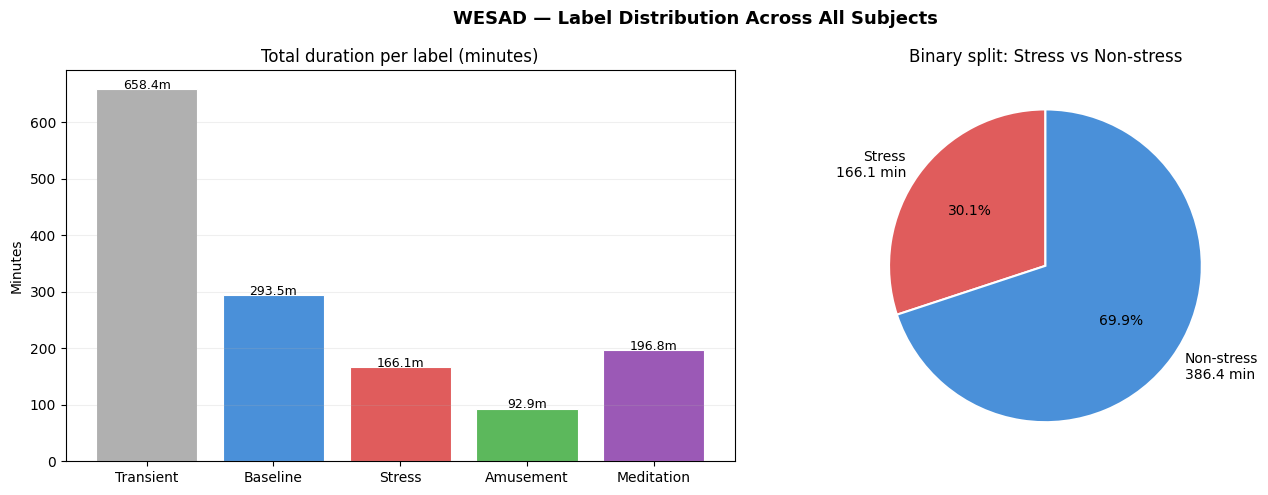

In [4]:
label_names = {0:'Transient', 1:'Baseline', 2:'Stress',
               3:'Amusement', 4:'Meditation'}

all_label_counts = {name: 0 for name in label_names.values()}

for sid, data in subjects.items():
    labels = data['label']
    for lval, lname in label_names.items():
        all_label_counts[lname] += np.sum(labels == lval)

# convert samples → minutes
label_minutes = {k: v / (CHEST_HZ * 60) for k, v in all_label_counts.items()}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('WESAD — Label Distribution Across All Subjects',
             fontsize=13, fontweight='bold')

colors = ['#b0b0b0','#4a90d9','#e05c5c','#5cb85c','#9b59b6']

axes[0].bar(label_minutes.keys(), label_minutes.values(),
            color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Total duration per label (minutes)')
axes[0].set_ylabel('Minutes')
for i, (k, v) in enumerate(label_minutes.items()):
    axes[0].text(i, v + 0.5, f'{v:.1f}m', ha='center', fontsize=9)
axes[0].grid(axis='y', alpha=0.2)

stress_min    = label_minutes['Stress']
nonstress_min = label_minutes['Baseline'] + label_minutes['Amusement']
axes[1].pie(
    [stress_min, nonstress_min],
    labels=[f'Stress\n{stress_min:.1f} min', f'Non-stress\n{nonstress_min:.1f} min'],
    colors=['#e05c5c','#4a90d9'],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
axes[1].set_title('Binary split: Stress vs Non-stress')

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(DATA_PATH), 'label_distribution.png'),
            dpi=120, bbox_inches='tight')
plt.show()

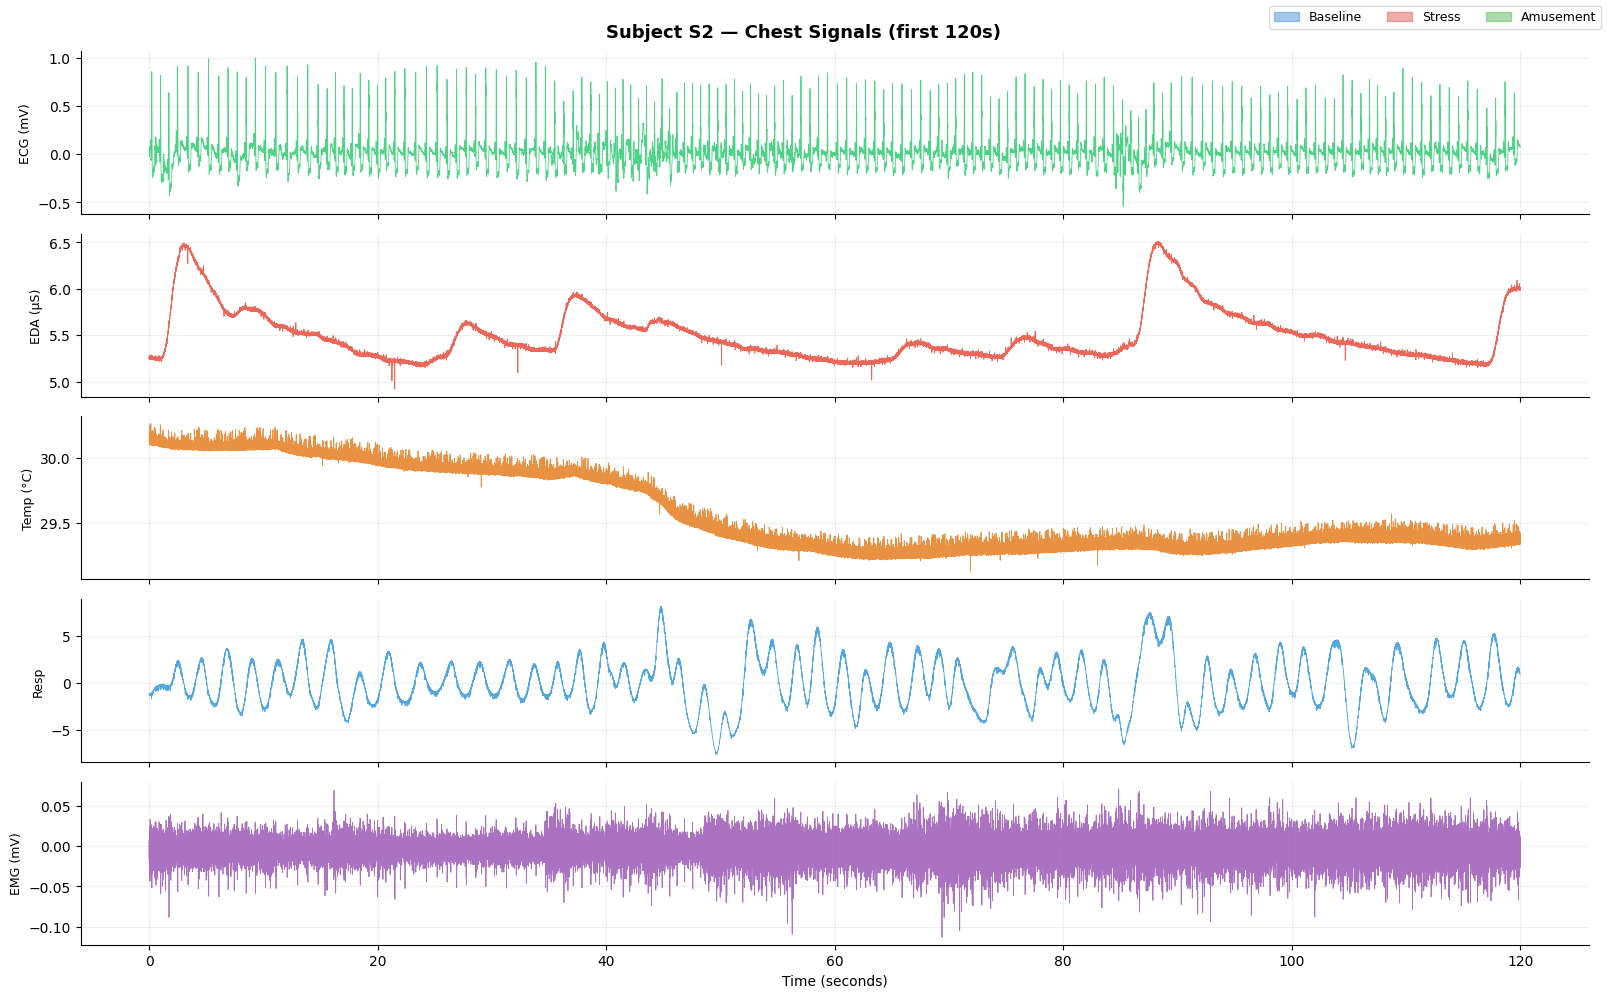

In [5]:
def plot_subject_signals(data, sid, duration_sec=120):
    chest  = data['signal']['chest']
    labels = data['label']
    n      = duration_sec * CHEST_HZ
    time   = np.arange(n) / CHEST_HZ

    signals = {
        'ECG (mV)' : chest['ECG'][:n, 0],
        'EDA (μS)' : chest['EDA'][:n, 0],
        'Temp (°C)': chest['Temp'][:n, 0],
        'Resp'     : chest['Resp'][:n, 0],
        'EMG (mV)' : chest['EMG'][:n, 0],
    }
    label_seg  = labels[:n]
    color_map  = {1:'#4a90d9', 2:'#e05c5c', 3:'#5cb85c'}
    sig_colors = ['#2ecc71','#e74c3c','#e67e22','#3498db','#9b59b6']

    fig, axes = plt.subplots(len(signals), 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Subject {sid} — Chest Signals (first {duration_sec}s)',
                 fontsize=13, fontweight='bold')

    for ax, (name, sig), col in zip(axes, signals.items(), sig_colors):
        ax.plot(time, sig, color=col, linewidth=0.6, alpha=0.85)

        prev, start = label_seg[0], 0
        for i in range(1, len(label_seg)):
            if label_seg[i] != prev or i == len(label_seg)-1:
                if prev in color_map:
                    ax.axvspan(start/CHEST_HZ, i/CHEST_HZ,
                               alpha=0.12, color=color_map[prev])
                start, prev = i, label_seg[i]

        ax.set_ylabel(name, fontsize=9)
        ax.grid(True, alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    axes[-1].set_xlabel('Time (seconds)')

    patches = [mpatches.Patch(color=c, alpha=0.5, label=l)
               for l, c in zip(['Baseline','Stress','Amusement'],
                                ['#4a90d9','#e05c5c','#5cb85c'])]
    fig.legend(handles=patches, loc='upper right', ncol=3,
               fontsize=9, framealpha=0.7)

    plt.tight_layout()
    plt.savefig(os.path.join(os.path.dirname(DATA_PATH), f'signals_{sid}.png'),
                dpi=120, bbox_inches='tight')
    plt.show()

plot_subject_signals(subjects['S2'], 'S2', duration_sec=120)

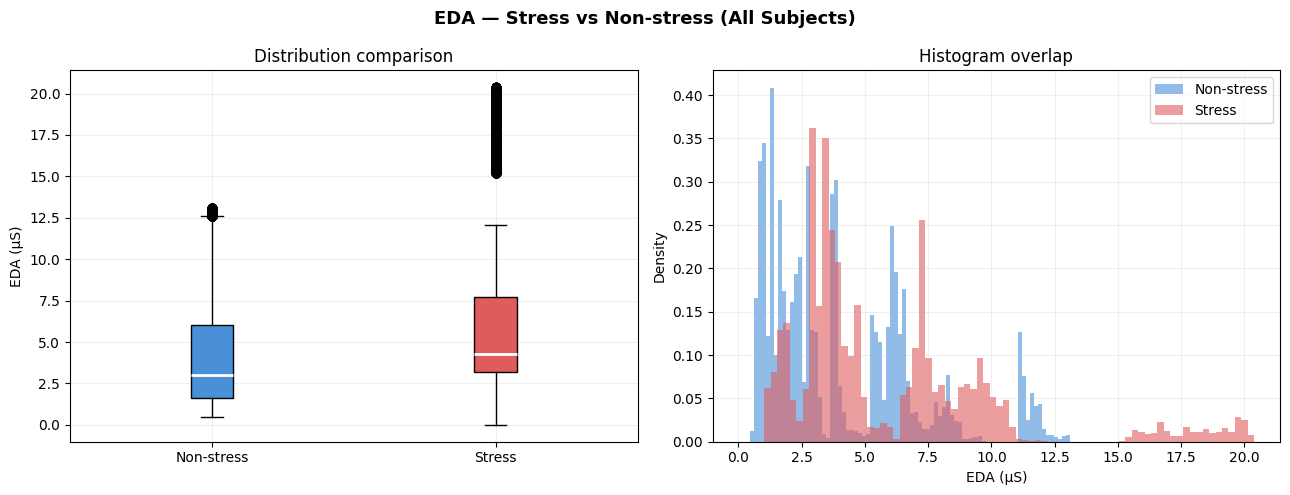

Stress EDA mean    : 5.9638
Non-stress EDA mean: 4.0296


In [6]:
stress_eda, nonstress_eda = [], []

for sid, data in subjects.items():
    eda    = data['signal']['chest']['EDA'][:, 0]
    labels = data['label']

    s_idx  = np.where(labels == 2)[0]
    ns_idx = np.where(np.isin(labels, [1, 3]))[0]

    if len(s_idx)  > 50000: s_idx  = np.random.choice(s_idx,  50000, replace=False)
    if len(ns_idx) > 50000: ns_idx = np.random.choice(ns_idx, 50000, replace=False)

    stress_eda.extend(eda[s_idx].tolist())
    nonstress_eda.extend(eda[ns_idx].tolist())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('EDA — Stress vs Non-stress (All Subjects)',
             fontsize=13, fontweight='bold')

bp = axes[0].boxplot([nonstress_eda, stress_eda],
                     labels=['Non-stress','Stress'],
                     patch_artist=True,
                     medianprops={'color':'white','linewidth':2})
bp['boxes'][0].set_facecolor('#4a90d9')
bp['boxes'][1].set_facecolor('#e05c5c')
axes[0].set_ylabel('EDA (μS)')
axes[0].set_title('Distribution comparison')
axes[0].grid(True, alpha=0.2)

axes[1].hist(nonstress_eda, bins=80, alpha=0.6,
             color='#4a90d9', label='Non-stress', density=True)
axes[1].hist(stress_eda,    bins=80, alpha=0.6,
             color='#e05c5c', label='Stress',     density=True)
axes[1].set_xlabel('EDA (μS)')
axes[1].set_ylabel('Density')
axes[1].set_title('Histogram overlap')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(os.path.join(os.path.dirname(DATA_PATH), 'eda_comparison.png'),
            dpi=120, bbox_inches='tight')
plt.show()

print(f"Stress EDA mean    : {np.mean(stress_eda):.4f}")
print(f"Non-stress EDA mean: {np.mean(nonstress_eda):.4f}")

In [7]:
summary = []
for sid, data in subjects.items():
    labels = data['label']
    total  = len(labels) / (CHEST_HZ * 60)
    s_min  = np.sum(labels == 2)           / (CHEST_HZ * 60)
    b_min  = np.sum(labels == 1)           / (CHEST_HZ * 60)
    a_min  = np.sum(labels == 3)           / (CHEST_HZ * 60)
    summary.append({
        'Subject'       : sid,
        'Total (min)'   : round(total, 1),
        'Stress (min)'  : round(s_min, 1),
        'Baseline (min)': round(b_min, 1),
        'Amusement(min)': round(a_min, 1),
        'Stress %'      : round(s_min / total * 100, 1)
    })

df = pd.DataFrame(summary)
print("=" * 62)
print("SUBJECT-WISE SUMMARY")
print("=" * 62)
print(df.to_string(index=False))
print("=" * 62)
print(f"\nAvg stress per subject : {df['Stress (min)'].mean():.1f} min")
print(f"Avg stress %           : {df['Stress %'].mean():.1f}%")
print("\nNB01 complete ✓  →  proceed to NB02")

SUBJECT-WISE SUMMARY
Subject  Total (min)  Stress (min)  Baseline (min)  Amusement(min)  Stress %
     S2        101.3          10.2            19.1             6.0      10.1
     S3        108.2          10.7            19.0             6.2       9.9
     S4        107.0          10.6            19.3             6.2       9.9
     S5        104.3          10.8            20.0             6.2      10.3
     S6        117.8          10.8            19.7             6.2       9.2
     S7         87.3          10.7            19.8             6.2      12.2
     S8         91.1          11.2            19.5             6.2      12.3
     S9         87.0          10.8            19.7             6.2      12.3
    S10         91.6          12.1            19.7             6.2      13.2
    S11         87.2          11.3            19.7             6.1      13.0
    S13         92.3          11.1            19.7             6.4      12.0
    S14         92.5          11.2            19.7     